<a href="https://colab.research.google.com/github/raddified/Msia_Sign_Language_Recognition/blob/data_preprocessing/MSLR_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIM Dataset V3 Video Exploration and Splitting

## Notebook Overview

This notebook processes and splits the 'BIM Dataset V3' of sign language videos. The main goal is to clean the dataset by identifying correctly named videos and then splitting them into training and testing sets while ensuring data integrity.

### Workflow:

1.  **Import Libraries**: Essential libraries like `os`, `pandas`, `numpy`, `shutil`, `random`, `matplotlib.pyplot`, `seaborn`, and `sklearn.model_selection` are imported for data manipulation, visualization, and splitting.
2.  **Mount Google Drive**: The notebook mounts Google Drive to access the dataset stored there.
3.  **Unzip Dataset**: The `BIM Dataset V3.zip` file is unzipped into the Colab environment.
4.  **Initial Data Exploration**: The notebook lists the gestures (folders) in the dataset and performs an initial analysis to understand the naming conventions of the video files within these folders. It identifies videos that are correctly named according to their parent folder and those that might be incorrectly named or in the wrong folders.
5.  **Data Cleaning and Filtering**:
    *   An `eng_mapping` dictionary is used to handle English-to-Malay gesture name translations for correctness checks.
    *   A DataFrame `df` is created to categorize each video based on its `gesture` (folder name), `name` (extracted from video filename), `correctness` (whether the video name matches the gesture), and `wrong_folder` (whether the cleaned video name exists in the list of valid gestures, indicating if it's a video for another gesture placed in the current folder).
    *   The `result` DataFrame aggregates these counts, providing a detailed breakdown.
    *   The notebook then filters for `correct_name` videos (correctly named videos in their respective folders) and `vid_50m` (gestures with more than 50 correct videos) to focus on a robust subset of the data.
6.  **Visualization of Video Counts**: Bar plots are generated to visualize:
    *   The total number of videos per gesture (`result_sum`).
    *   The number of videos for gestures with more than 50 correctly named videos (`vid_50m`).
    *   The `plot_bar_count` function is defined to standardize plot generation.
7.  **Dataset Splitting**:
    *   A `GESTURE_DICT` is created, mapping each valid gesture to its allowed video name variations.
    *   An output directory structure (`/content/drive/MyDrive/Group_Assignment/BIM_Dataset_V3_split/trainset` and `testset`) is created.
    *   The notebook iterates through the gestures, collecting paths of valid videos. For the 'hi' gesture, it performs downsampling to a maximum of 150 videos.
    *   `train_test_split` from `sklearn.model_selection` is used to split the collected valid video files into training (90%) and testing (10%) sets, ensuring stratification by gesture to maintain class distribution.
    *   The `move_files` function copies the video files to their respective `trainset` and `testset` directories.
8.  **Recheck Train and Test Size**: After splitting, the notebook re-counts the number of videos in the `trainset` and `testset` for each gesture and visualizes these counts using bar plots (`Train Count` and `Test Count`). This step confirms that the splitting process was successful and the distribution across subsets is as expected.

## 1.Import Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import shutil
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## 2.Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3.Unzip Dataset

In [ ]:
!unzip "/content/drive/MyDrive/Colab Notebooks/WQF7006/BIM Dataset V3.zip"

Streaming output truncated to the last 5000 lines.
  inflating: BIM Dataset V3/beli/beli_13_4_2.mp4  
  inflating: BIM Dataset V3/beli/beli_13_4_3.mp4  
  inflating: BIM Dataset V3/beli/beli_13_5_1.mp4  
  inflating: BIM Dataset V3/beli/beli_13_5_2.mp4  
  inflating: BIM Dataset V3/beli/beli_13_5_3.mp4  
   creating: BIM Dataset V3/berjalan/
  inflating: BIM Dataset V3/berjalan/berjalan_04_01_01.mp4  
  inflating: BIM Dataset V3/berjalan/berjalan_04_01_02.mp4  
  inflating: BIM Dataset V3/berjalan/berjalan_04_01_03.mp4  
  inflating: BIM Dataset V3/berjalan/berjalan_04_02_01.mp4  
  inflating: BIM Dataset V3/berjalan/berjalan_04_02_02.mp4  
  inflating: BIM Dataset V3/berjalan/berjalan_04_02_03.mp4  
  inflating: BIM Dataset V3/berjalan/berjalan_04_03_01.mp4  
  inflating: BIM Dataset V3/berjalan/berjalan_04_03_02.mp4  
  inflating: BIM Dataset V3/berjalan/berjalan_04_03_03.mp4  
  inflating: BIM Dataset V3/berjalan/berjalan_04_04_01.mp4  
  inflating: BIM Dataset V3/berjalan/berjalan_

## 4.Initial Data Exploration

In [ ]:
VIDEO_DIRECTORY = r'/content/BIM Dataset V3'

# Get all file names in the directory
gestures = os.listdir(VIDEO_DIRECTORY)
print(len(gestures))

90


## 5.Data Cleaning and Filtering

In [ ]:
data = []
# Pre-clean gestures for faster lookup
# Some gesture set into Ensligh name or wrong format
gestures_clean = [g.lower().replace("_", "") for g in gestures]
eng_mapping = {"arah":"direction"
                ,"buat":"do"
                ,"emak":"mother"
                ,"panas":"hot"
                ,"pergi":"go"
                ,"pinjam":"borrow"
                ,"sekolah":"school"
                ,"tidur":"sleep"}
eng_to_ind = {v.lower(): k.lower().replace("_", "") for k, v in eng_mapping.items()}

for ges in gestures:
    ges_clean = ges.lower().replace("_", "")
    path = os.path.join(VIDEO_DIRECTORY, ges)

    if not os.path.isdir(path):
        continue

    for vid in os.listdir(path):
        if not vid.endswith(".mp4"):
            continue

        name_part = vid.rsplit("_", 3)[0]
        name_clean = name_part.lower().replace("_", "").replace(" ", "").replace("(ii)","2")

        # Logic for correctness and existence
        is_correct = (name_clean == ges_clean) or (eng_to_ind.get(name_clean) == ges_clean)
        correctness = "correct" if is_correct else "incorrect"
        exists = (name_clean in gestures_clean) or (name_clean in eng_to_ind)

        data.append([ges, name_part, correctness, exists])

# Create DataFrame and aggregate
df = pd.DataFrame(data, columns=["gesture", "name", "correctness", "wrong_folder"])
result = df.groupby(["gesture", "name", "correctness", "wrong_folder"]).size().reset_index(name="count")


In [ ]:
def plot_bar_count(df,X,Y,title):

  # Set a style for seaborn plots
  sns.set_style("whitegrid")

  # Create the plot
  plt.figure(figsize=(14, 7))
  sns.barplot(
      x=X,
      y=Y,
      data=df,
      palette='rocket',
      hue='gesture',
      legend=False
  )

  # Add title and labels for clarity
  plt.title(title, fontsize=16)
  plt.xlabel(X, fontsize=12)
  plt.ylabel('Number of Videos', fontsize=12)

  # Rotate x-axis labels for better readability if they overlap
  plt.xticks(rotation=45, ha='right', fontsize=10)
  plt.yticks(fontsize=10)

  # Ensure all elements fit tightly within the figure area
  plt.tight_layout()

  # Display the plot
  plt.show()

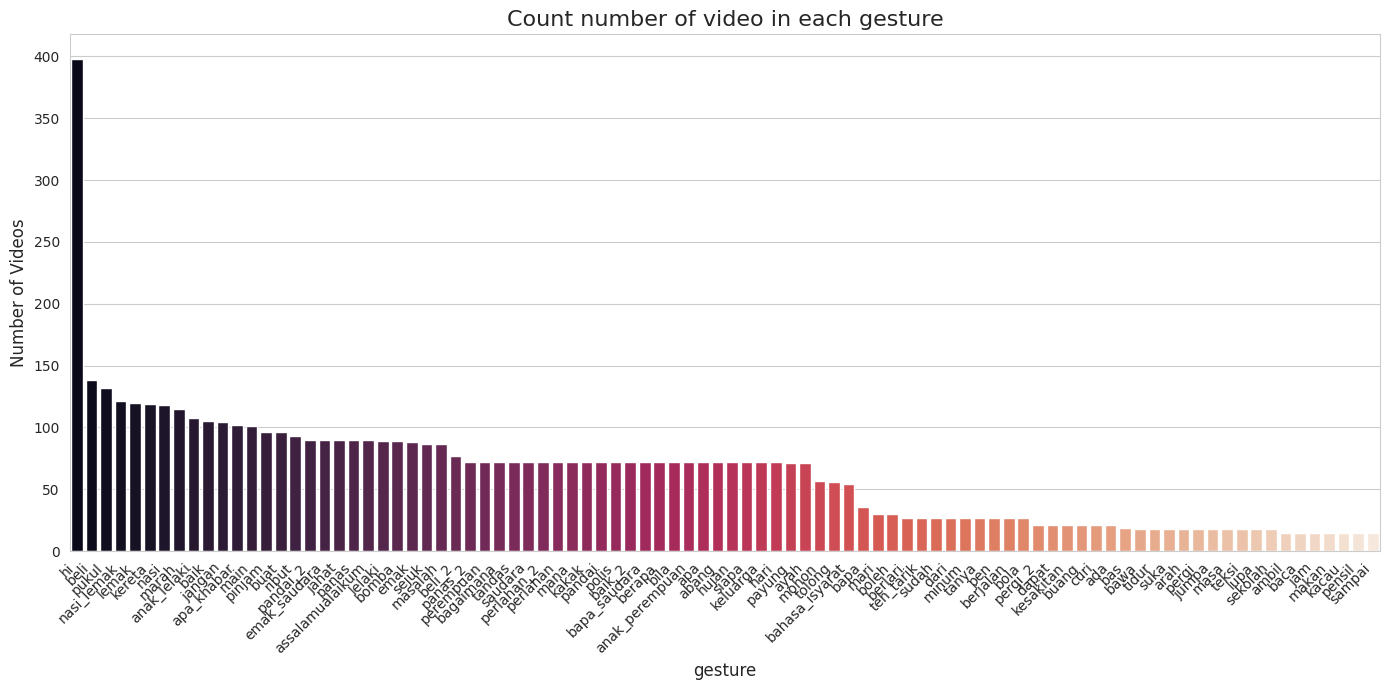

In [ ]:
result_sum = result.groupby('gesture').sum("count").sort_values(by='count', ascending=False).reset_index()

plot_bar_count(result_sum,"gesture","count","Count number of video in each gesture")

### Explore gesture and file name to recheck video

In [ ]:
result.loc[(result['wrong_folder'] == True) & (result['correctness'] == 'incorrect')]

,gesture,name,correctness,wrong_folder,count
5,anak_lelaki,anak_perempuan,incorrect,True,18
20,baik,baik (II),incorrect,True,18
23,bapa,bapa saudara,incorrect,True,18
29,beli,beli_2,incorrect,True,30


In [ ]:
result.loc[(result['wrong_folder'] == False) & (result['correctness'] == 'incorrect')]

,gesture,name,correctness,wrong_folder,count
51,hi,hai,incorrect,False,81
72,marah,marah (II),incorrect,False,18
73,marah,marah2,incorrect,False,76
79,mohon,mohon_2,incorrect,False,30
87,panas,panas1,incorrect,False,18
90,pandai,pandaoi,incorrect,False,1
92,pandai_2,smart,incorrect,False,18
110,saudara,saudara2,incorrect,False,18
122,tolong,tolong_2,incorrect,False,29


### Correct file naming in the correct gesture folder

In [ ]:
correct_name = result.loc[result['correctness'] == 'correct'].groupby('gesture').sum("count").sort_values(by='count', ascending=False).reset_index()
correct_name

,gesture,wrong_folder,count
0,hi,2,317
1,pukul,2,132
2,nasi_lemak,3,121
3,lemak,2,120
4,kereta,2,119
...,...,...,...
85,jam,1,15
86,makan,1,15
87,kacau,1,15
88,pensil,1,15


In [ ]:
# Select gesture + file name that have video more that 50

correct_name = (result.loc[result['correctness'] == 'correct']
                .groupby('gesture').sum("count").sort_values(by='count', ascending=False).reset_index())

vid_50m = correct_name.loc[correct_name["count"] > 50]
filtered_result = result[result['gesture'].isin(vid_50m['gesture']) & (result["correctness"] == "correct")]
display(filtered_result)

,gesture,name,correctness,wrong_folder,count
0,abang,abang,correct,True,72
3,anak_lelaki,anak lelaki,correct,True,18
4,anak_lelaki,anak_lelaki,correct,True,18
6,anak_lelaki,anaklelaki,correct,True,54
7,anak_perempuan,anak perempuan,correct,True,18
...,...,...,...,...,...
107,ribut,ribut,correct,True,78
109,saudara,saudara,correct,True,54
111,sejuk,sejuk,correct,True,87
113,siapa,siapa,correct,True,72


## 6.Visualization of Video Counts

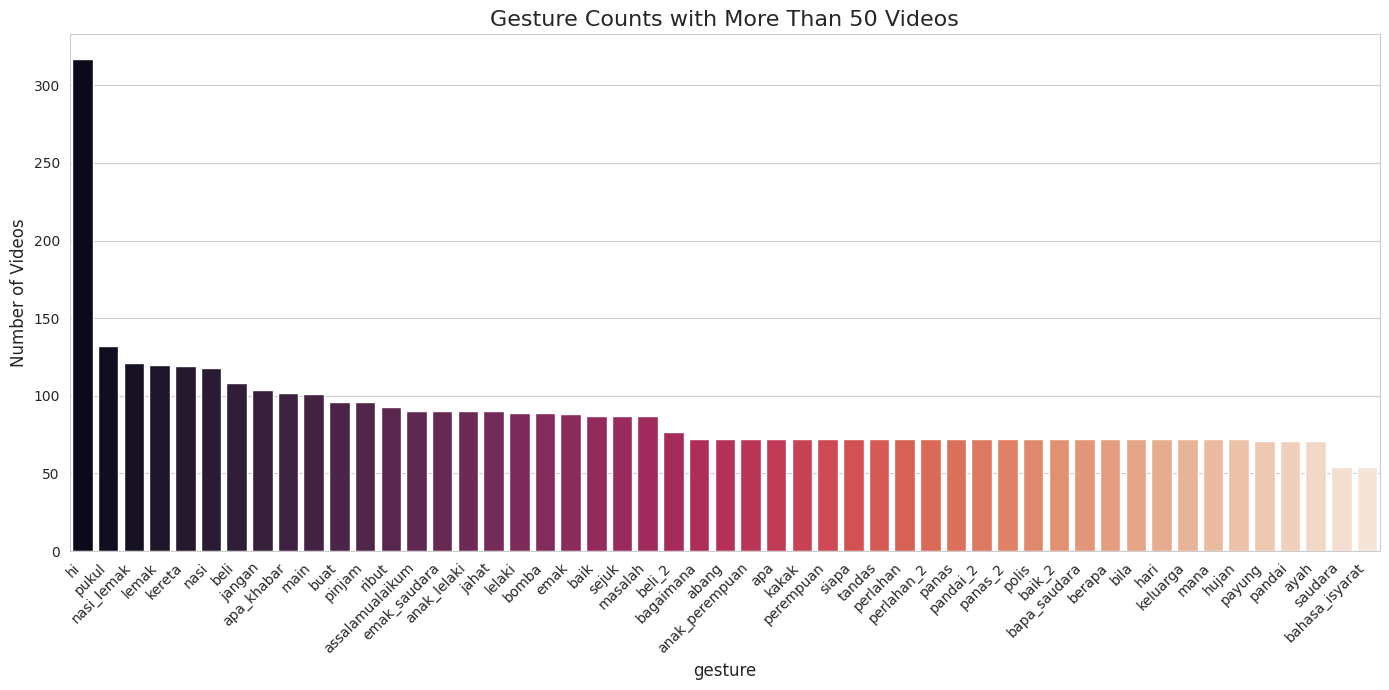

In [ ]:
plot_bar_count(vid_50m,"gesture","count","Gesture Counts with More Than 50 Videos")

##

## 7.Dataset Splitting

In [ ]:
GESTURE_DICT = filtered_result.groupby("gesture")["name"].unique().apply(list).to_dict()

BASE_OUTPUT = '/content/drive/MyDrive/Group_Assignment/BIM_Dataset_V3_split'
# create folder if not exist
os.makedirs(os.path.join(BASE_OUTPUT, 'trainset'), exist_ok=True)
os.makedirs(os.path.join(BASE_OUTPUT, 'testset'), exist_ok=True)

In [ ]:
# 1. Collect only valid files
valid_files_map = {} # Using a dictionary to group by gesture for easier downsampling

for ges, allowed_names in GESTURE_DICT.items():
    path = os.path.join(VIDEO_DIRECTORY, ges)
    if not os.path.exists(path):
        continue

    current_gesture_files = []
    for vid in os.listdir(path):
        if not vid.endswith(".mp4"):
            continue

        # Extract the gesture name part using your rsplit logic
        name_part = vid.rsplit("_", 3)[0]

        if name_part in allowed_names:
            current_gesture_files.append((os.path.join(path, vid), ges, vid))

    # --- DOWNSAMPLING LOGIC ---
    # If the gesture is 'hi' and has more than 150 videos, pick 150 randomly
    if ges.lower() == 'hi' and len(current_gesture_files) > 150:
        print(f"Downsampling {ges}: Reducing {len(current_gesture_files)} to 150.")
        current_gesture_files = random.sample(current_gesture_files, 150)

    valid_files_map[ges] = current_gesture_files

# Flatten the map back into a single list for splitting
all_valid_files = []
all_labels = []
for ges, files in valid_files_map.items():
    all_valid_files.extend(files)
    all_labels.extend([ges] * len(files))

# 2. Split and Move (90:10 ratio)
train_files, test_files = train_test_split(all_valid_files, test_size=0.10, random_state=42,stratify=all_labels)

def move_files(file_list, subset):
    for src, ges, fname in file_list:
        dest_dir = os.path.join(BASE_OUTPUT, subset, ges)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy2(src, os.path.join(dest_dir, fname))

move_files(train_files, 'trainset')
move_files(test_files, 'testset')

print(f"Successfully processed {len(all_valid_files)} total videos.")
print(f"Moved {len(train_files)} to Train and {len(test_files)} to Test.")

Downsampling hi: Reducing 317 to 150.
Successfully processed 4329 total videos.
Moved 3896 to Train and 433 to Test.


## 8.Recheck Train and Test Size

In [ ]:
final_gestures = os.listdir(os.path.join(BASE_OUTPUT,"trainset"))
train_count = []
test_count = []

for ges in final_gestures:
    vid_train_count = len(os.listdir(os.path.join(BASE_OUTPUT,"trainset",ges)))
    vid_test_count = len(os.listdir(os.path.join(BASE_OUTPUT,"testset",ges)))
    train_count.append(vid_train_count)
    test_count.append(vid_test_count)

recheck_df = pd.DataFrame({
    "gesture": final_gestures,
    "train_count": train_count,
    "test_count": test_count
})

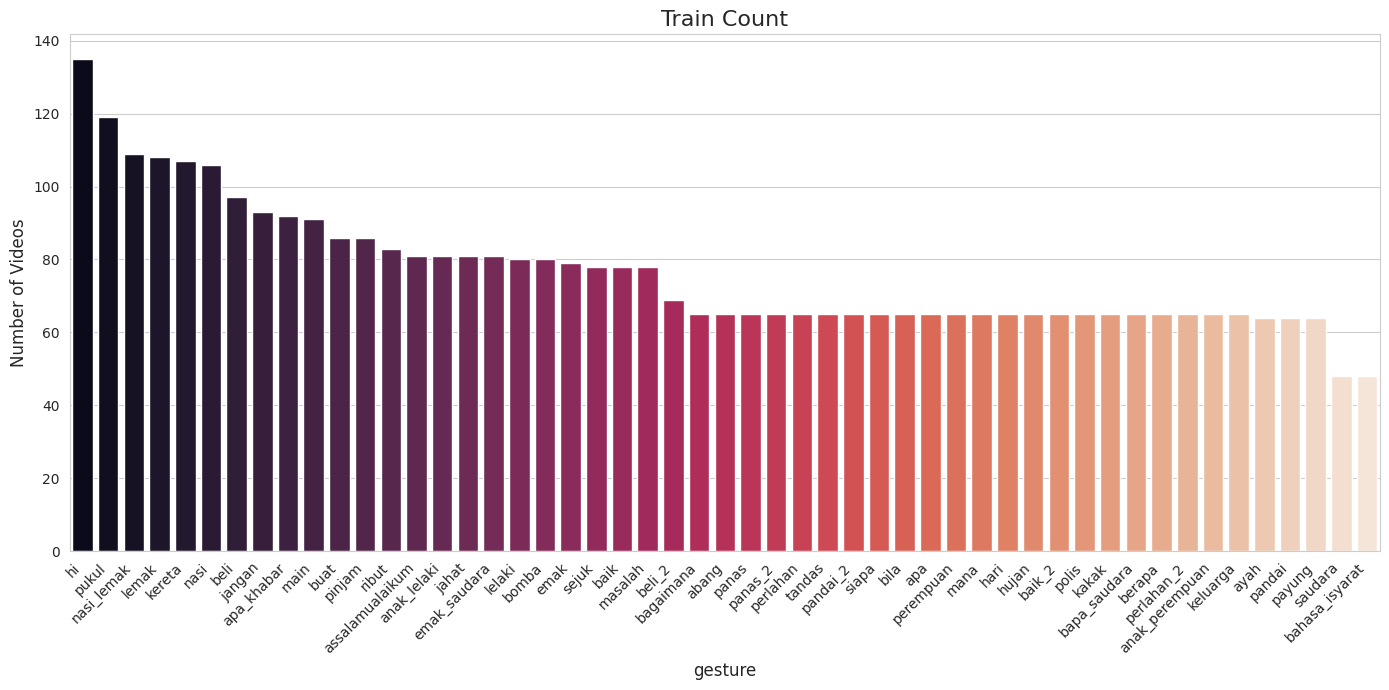

In [ ]:
plot_bar_count(recheck_df.sort_values("train_count",ascending=False),"gesture","train_count","Train Count")

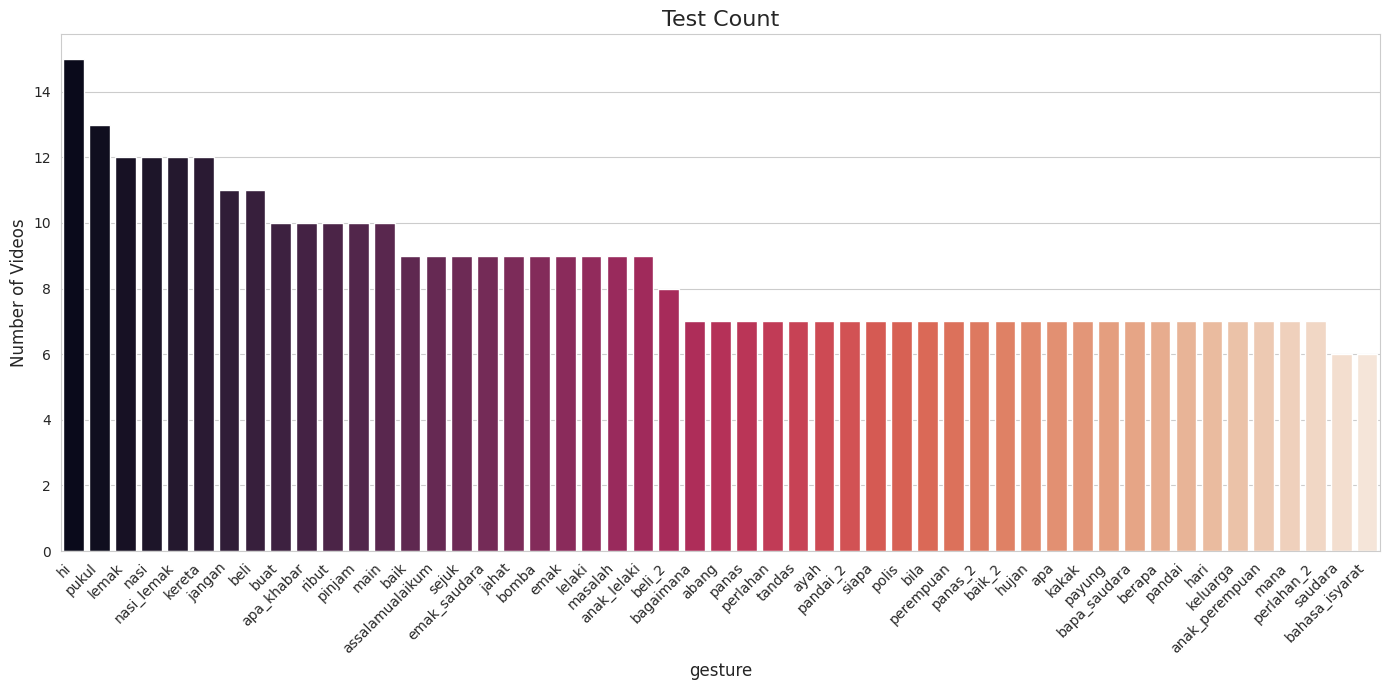

In [ ]:
plot_bar_count(recheck_df.sort_values("test_count",ascending=False),"gesture","test_count","Test Count")